In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm, parallel
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import re
big_plt_font()

In [2]:
home_dir = r'D:\\'
data_dir = home_dir + f'data/experiment_07142026'

In [3]:
file = load_h5_data('TipVoltageSweep_09-24-05.h5', base=data_dir)

In [4]:
all_I, all_V = file['all_I'], file['all_V'][5:]
all_I = all_I*file['R']/parallel(file['R'], 10e6)
all_I_mean, all_I_std = np.mean(all_I, axis=1)[5:], np.std(all_I, axis=1)[5:]

--- Fit Results ---
alpha : 3.513304e+00 ± 1.471938e+00 nA/V^2
beta  : 7011.7807 ± 603.1150 V
V0    : 301.9429 ± 25.9023 V
I0    : 0.7785 ± 0.0417 nA


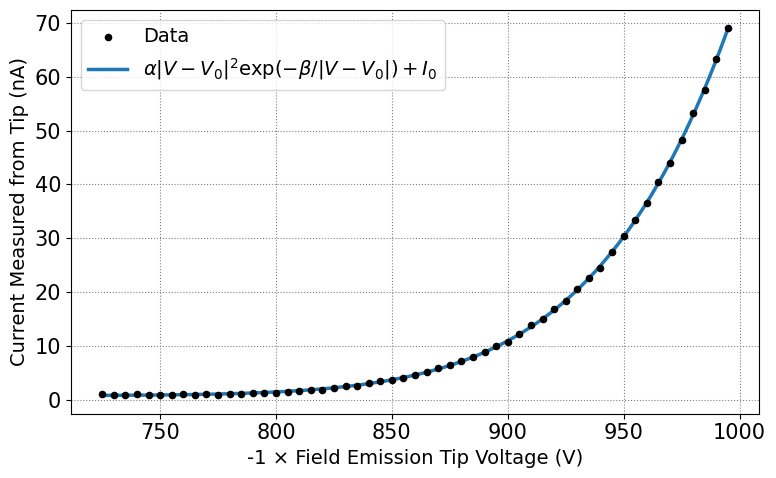

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the model function with x and y offsets
def fowler_nordheim(x, alpha, beta, x0, y0):
    """
    Fowler-Nordheim model with offsets:
    y = alpha * |x - x0|^2 * exp(-beta / |x - x0|) + y0
    """
    v_eff = np.abs(x - x0)
    
    # Safely handle division by zero or zero effectively
    with np.errstate(divide='ignore', invalid='ignore'):
        y = alpha * (v_eff**2) * np.exp(-beta / v_eff) + y0
        y = np.nan_to_num(y, nan=y0, posinf=y0, neginf=y0)
        
    return y

# -----------------------------------------------------------------------------
# 2. Example Data Generation (Replace this section with your real x_data & y_data)
# -----------------------------------------------------------------------------
x_data = all_V 
y_noisy = all_I_mean*1e9

# -----------------------------------------------------------------------------
# 3. Fitting Configuration
# -----------------------------------------------------------------------------
# Exponential fits are sensitive to initial parameter estimates (p0).
# Adjust these starting values if your fit fails to converge.
p0 = [1e-4, 800.0, 0.0, 0.0]  # Initial guesses: [alpha, beta, x0, y0]

# Parameter bounds: [lower bounds], [upper bounds]
bounds = (
    [0.0, 0.0, -np.inf, -np.inf],  # alpha and beta should be non-negative
    [np.inf, np.inf, np.inf, np.inf]
)

# Execute the curve fit
popt, pcov = curve_fit(
    fowler_nordheim, 
    x_data, 
    y_noisy, 
    p0=p0, 
    bounds=bounds,
    maxfev=10000
)

# Extract standard errors (1-sigma standard deviation)
perr = np.sqrt(np.diag(pcov))
alpha_fit, beta_fit, x0_fit, y0_fit = popt

# Print fit parameters and uncertainties
print("--- Fit Results ---")
print(f"alpha : {alpha_fit:.6e} ± {perr[0]:.6e} nA/V^2")
print(f"beta  : {beta_fit:.4f} ± {perr[1]:.4f} V")
print(f"V0    : {x0_fit:.4f} ± {perr[2]:.4f} V")
print(f"I0    : {y0_fit:.4f} ± {perr[3]:.4f} nA")

# -----------------------------------------------------------------------------
# 4. Plotting
# -----------------------------------------------------------------------------
x_smooth = np.linspace(min(x_data), max(x_data), 500)
y_fit = fowler_nordheim(x_smooth, *popt)

plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_noisy, color='black', label='Data', zorder=3, s=20)
plt.plot(x_smooth, y_fit, color='C0', 
         label=r'$\alpha|V-V_0|^2 \exp(-\beta/|V-V_0|) + I_0$')
plt.xlabel('-1 × Field Emission Tip Voltage (V)')
plt.ylabel('Current Measured from Tip (nA)')
plt.grid(True, linestyle=':', color='gray')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

--- Fit Results ---
alpha : 3.513304e+00 ± 1.471938e+00 nA/V^2
beta  : 7011.7807 ± 603.1150 V
V0    : 301.9429 ± 25.9023 V
I0    : 0.7785 ± 0.0417 nA


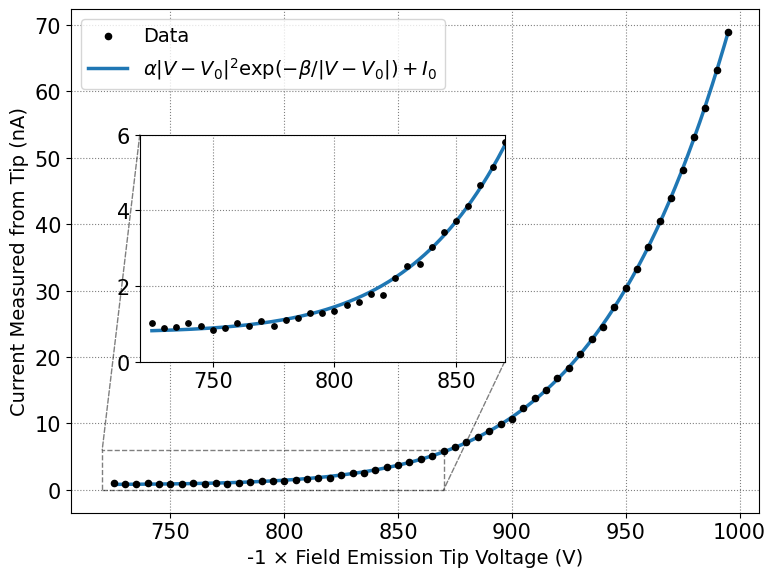

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the model function with x and y offsets
def fowler_nordheim(x, alpha, beta, x0, y0):
    """
    Fowler-Nordheim model with offsets:
    y = alpha * |x - x0|^2 * exp(-beta / |x - x0|) + y0
    """
    v_eff = np.abs(x - x0)
    
    # Safely handle division by zero or zero effectively
    with np.errstate(divide='ignore', invalid='ignore'):
        y = alpha * (v_eff**2) * np.exp(-beta / v_eff) + y0
        y = np.nan_to_num(y, nan=y0, posinf=y0, neginf=y0)
        
    return y

# -----------------------------------------------------------------------------
# 2. Example Data Generation (Replace this section with your real x_data & y_data)
# -----------------------------------------------------------------------------
x_data = all_V 
y_noisy = all_I_mean * 1e9

# -----------------------------------------------------------------------------
# 3. Fitting Configuration
# -----------------------------------------------------------------------------
p0 = [1e-4, 800.0, 0.0, 0.0]  # Initial guesses: [alpha, beta, x0, y0]

bounds = (
    [0.0, 0.0, -np.inf, -np.inf],
    [np.inf, np.inf, np.inf, np.inf]
)

popt, pcov = curve_fit(
    fowler_nordheim, 
    x_data, 
    y_noisy, 
    p0=p0, 
    bounds=bounds,
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))
alpha_fit, beta_fit, x0_fit, y0_fit = popt

print("--- Fit Results ---")
print(f"alpha : {alpha_fit:.6e} ± {perr[0]:.6e} nA/V^2")
print(f"beta  : {beta_fit:.4f} ± {perr[1]:.4f} V")
print(f"V0    : {x0_fit:.4f} ± {perr[2]:.4f} V")
print(f"I0    : {y0_fit:.4f} ± {perr[3]:.4f} nA")

# -----------------------------------------------------------------------------
# 4. Plotting with Inset Zoom
# -----------------------------------------------------------------------------
x_smooth = np.linspace(min(x_data), max(x_data), 500)
y_fit = fowler_nordheim(x_smooth, *popt)

# Create figure and main axis object
fig, ax = plt.subplots(figsize=(8, 6))

# --- Main Plot ---
ax.scatter(x_data, y_noisy, color='black', label='Data', zorder=3, s=20)
ax.plot(x_smooth, y_fit, color='C0', 
        label=r'$\alpha|V-V_0|^2 \exp(-\beta/|V-V_0|) + I_0$')

ax.set_xlabel('-1 × Field Emission Tip Voltage (V)')
ax.set_ylabel('Current Measured from Tip (nA)')
ax.grid(True, linestyle=':', color='gray')
ax.legend(loc='upper left', frameon=True)

# --- Inset Axis Creation ---
# Define inset location in relative main plot coordinates: [left, bottom, width, height]
# (0.15 = 15% from left, 0.45 = 45% from bottom, 0.40 = 40% wide, 0.45 = 45% tall)
ax_inset = ax.inset_axes([0.1, 0.3, 0.53, 0.45])

# Plot data and fit curve on the inset axis
ax_inset.scatter(x_data, y_noisy, color='black', zorder=3, s=15)
ax_inset.plot(x_smooth, y_fit, color='C0')

# Set zoomed-in limits
ax_inset.set_xlim(720, 870)
ax_inset.set_ylim(0, 6)
ax_inset.grid(True, linestyle=':', color='gray')

# Draw bounding box and connecting lines from the zoom region on the main plot to the inset
# 1. Unpack the rectangle indicator and connecting lines
rect, connectors = ax.indicate_inset_zoom(ax_inset, edgecolor='black', linestyle='--')

# 2. Apply dashed line style to the connecting lines
for line in connectors:
    line.set_linestyle('--')

plt.tight_layout()
plt.show()

--- Fit Results ---
alpha : 5.324967e+02 ± 3.245961e+01 nA/V^2
beta  : 15772.8592 ± 59.9697 V
I0    : 0.5149 ± 0.0449 nA


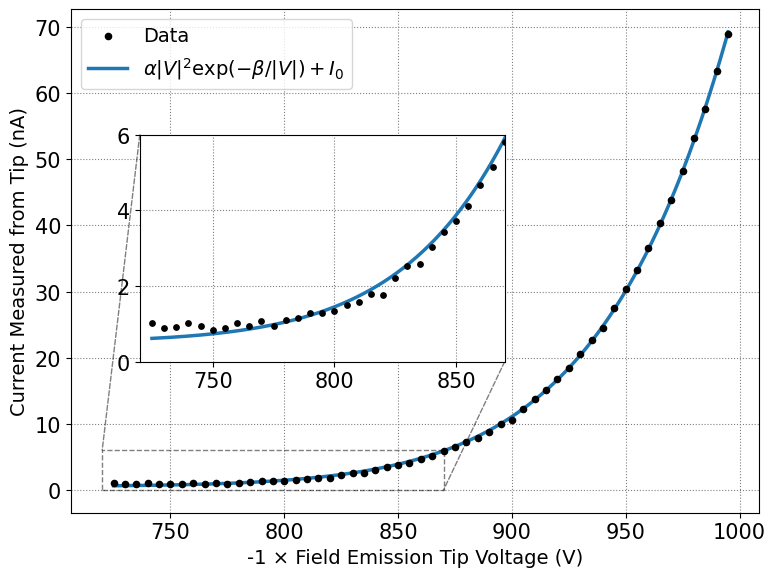

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the model function with x and y offsets
def fowler_nordheim(x, alpha, beta, y0):
    """
    Fowler-Nordheim model with offsets:
    y = alpha * |x - x0|^2 * exp(-beta / |x - x0|) + y0
    """
    v_eff = np.abs(x)
    
    # Safely handle division by zero or zero effectively
    with np.errstate(divide='ignore', invalid='ignore'):
        y = alpha * (v_eff**2) * np.exp(-beta / v_eff) + y0
        y = np.nan_to_num(y, nan=y0, posinf=y0, neginf=y0)
        
    return y

# -----------------------------------------------------------------------------
# 2. Example Data Generation (Replace this section with your real x_data & y_data)
# -----------------------------------------------------------------------------
x_data = all_V 
y_noisy = all_I_mean * 1e9

# -----------------------------------------------------------------------------
# 3. Fitting Configuration
# -----------------------------------------------------------------------------
p0 = [1e-4, 800.0, 0.0]  # Initial guesses: [alpha, beta, x0, y0]

bounds = (
    [0.0, 0.0, -np.inf],
    [np.inf, np.inf, np.inf]
)

popt, pcov = curve_fit(
    fowler_nordheim, 
    x_data, 
    y_noisy, 
    p0=p0, 
    bounds=bounds,
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))
alpha_fit, beta_fit, y0_fit = popt

print("--- Fit Results ---")
print(f"alpha : {alpha_fit:.6e} ± {perr[0]:.6e} nA/V^2")
print(f"beta  : {beta_fit:.4f} ± {perr[1]:.4f} V")
# print(f"V0    : {x0_fit:.4f} ± {perr[2]:.4f} V")
print(f"I0    : {y0_fit:.4f} ± {perr[2]:.4f} nA")

# -----------------------------------------------------------------------------
# 4. Plotting with Inset Zoom
# -----------------------------------------------------------------------------
x_smooth = np.linspace(min(x_data), max(x_data), 500)
y_fit = fowler_nordheim(x_smooth, *popt)

# Create figure and main axis object
fig, ax = plt.subplots(figsize=(8, 6))

# --- Main Plot ---
ax.scatter(x_data, y_noisy, color='black', label='Data', zorder=3, s=20)
ax.plot(x_smooth, y_fit, color='C0', 
        label=r'$\alpha|V|^2 \exp(-\beta/|V|) + I_0$')

ax.set_xlabel('-1 × Field Emission Tip Voltage (V)')
ax.set_ylabel('Current Measured from Tip (nA)')
ax.grid(True, linestyle=':', color='gray')
ax.legend(loc='upper left', frameon=True)

# --- Inset Axis Creation ---
# Define inset location in relative main plot coordinates: [left, bottom, width, height]
# (0.15 = 15% from left, 0.45 = 45% from bottom, 0.40 = 40% wide, 0.45 = 45% tall)
ax_inset = ax.inset_axes([0.1, 0.3, 0.53, 0.45])

# Plot data and fit curve on the inset axis
ax_inset.scatter(x_data, y_noisy, color='black', zorder=3, s=15)
ax_inset.plot(x_smooth, y_fit, color='C0')

# Set zoomed-in limits
ax_inset.set_xlim(720, 870)
ax_inset.set_ylim(0, 6)
ax_inset.grid(True, linestyle=':', color='gray')

# Draw bounding box and connecting lines from the zoom region on the main plot to the inset
# 1. Unpack the rectangle indicator and connecting lines
rect, connectors = ax.indicate_inset_zoom(ax_inset, edgecolor='black', linestyle='--')

# 2. Apply dashed line style to the connecting lines
for line in connectors:
    line.set_linestyle('--')

plt.tight_layout()
plt.show()